In [45]:
import pandas as pd
import numpy as np

# -------------------------------
# 1. Load Data
# -------------------------------
df = pd.read_csv("vgsales_cleaned.csv")

# -------------------------------
# 2. Recalculate Game_Age (BEST PRACTICE)
# -------------------------------
current_year = 2026
df["Game_Age"] = current_year - df["Year"]

# Remove invalid ages (<=0)
df = df[df["Game_Age"] > 0]

df["Total_Sales_Check"] = df['EU_Sales']+df['JP_Sales']+df['NA_Sales']+df['Other_Sales']
# -------------------------------
# 3. Validate Cleaning
# -------------------------------
df["Sales_Diff"] = abs(df["Total_Sales_Check"] - df["Global_Sales"])

threshold = 0.01
mismatch_count = (df["Sales_Diff"] > threshold).sum()
print("Mismatch Count:", mismatch_count)

# -------------------------------
# 4. Handle Inconsistencies
# -------------------------------
df = df[df["Sales_Diff"] <= threshold]

# -------------------------------
# 5. Feature Engineering
# -------------------------------

# Sales per year
df["Sales_Per_Year"] = df["Global_Sales"] / df["Game_Age"]

# Hit Game (based on median)
median_sales = df["Global_Sales"].median()
df["Hit_Game"] = (df["Global_Sales"] > median_sales).astype(int)

# -------------------------------
# 6. Top 3 Genres per Decade
# -------------------------------
genre_sales = (
    df.groupby(["Decade", "Genre"])["Global_Sales"]
    .sum()
    .reset_index()
)

top_genres = (
    genre_sales
    .sort_values(["Decade", "Global_Sales"], ascending=[True, False])
    .groupby("Decade")
    .head(3)
)

print("\nTop 3 Genres per Decade:")
print(top_genres)

# -------------------------------
# 7. Trend of Global Sales
# -------------------------------
sales_trend = (
    df.groupby("Year")["Global_Sales"]
    .sum()
    .reset_index()
)

print("\nSales Trend (First 10 rows):")
print(sales_trend.head(10))

# -------------------------------
# 8. Pivot Table (Genre vs Platform)
# -------------------------------
pivot_table = pd.pivot_table(
    df,
    values="Global_Sales",
    index="Genre",
    columns="Platform",
    aggfunc="sum",
    fill_value=0
)

print("\nPivot Table (sample):")
print(pivot_table.head())

# -------------------------------
# 9. Save Final Dataset
# -------------------------------
df.to_csv("final_vgsales.csv", index=False)

print("\n✅ Final dataset saved as final_vgsales.csv")

Mismatch Count: 2636

Top 3 Genres per Decade:
    Decade         Genre  Global_Sales
4     1980      Platform        122.27
5     1980        Puzzle         60.50
8     1980       Shooter         54.77
15    1990      Platform        155.39
18    1990  Role-Playing        146.75
17    1990        Racing        125.26
23    2000        Action        715.53
33    2000        Sports        682.27
26    2000          Misc        373.79
35    2010        Action        530.44
43    2010       Shooter        330.86
45    2010        Sports        265.65
47    2020    Simulation          0.29

Sales Trend (First 10 rows):
   Year  Global_Sales
0  1980         10.89
1  1981         30.47
2  1982         24.58
3  1983         15.64
4  1984         50.36
5  1985         53.91
6  1986         35.64
7  1987         21.03
8  1988         47.22
9  1989         71.78

Pivot Table (sample):
Platform    2600   3DO    3DS    DC      DS     GB    GBA     GC   GEN    GG  \
Genre                           

In [91]:
import pandas as pd
import numpy as np

# ML imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# -------------------------------
# 1. Load Data
# -------------------------------
df = pd.read_csv("final_vgsales.csv")

# -------------------------------
# 2. Define Target
# -------------------------------
y = df["Hit_Game"]

# -------------------------------
# 3. Remove Data Leakage
# -------------------------------
drop_cols = [
    "Global_Sales",
    "Total_Sales_Check",
    "Sales_Per_Year",
    "Hit_Game",
    "Name"
]

X = df.drop(columns=drop_cols)

# -------------------------------
# 4. Column Types
# -------------------------------
categorical_cols = ["Platform", "Genre", "Publisher"]
numeric_cols = ["Year", "Game_Age"]

# -------------------------------
# 5. Preprocessing (Encoding)
# -------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# -------------------------------
# 6. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 7. Models
# -------------------------------

# Logistic Regression
log_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Random Forest
rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

# -------------------------------
# 8. Train Models
# -------------------------------
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# -------------------------------
# 9. Predictions
# -------------------------------
y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# -------------------------------
# 10. Evaluation Function
# -------------------------------
def evaluate(y_true, y_pred, name):
    print(f"\n===== {name} =====")

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("Confusion Matrix:\n", cm)

    TN, FP, FN, TP = cm.ravel()

    print("TN:", TN, "| FP:", FP, "| FN:", FN, "| TP:", TP)

# -------------------------------
# 11. Evaluate Models
# -------------------------------
evaluate(y_test, y_pred_log, "Logistic Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

# -------------------------------
# 12. Feature Importance (RF)
# -------------------------------
ohe = rf_model.named_steps["preprocessing"].named_transformers_["cat"]
encoded_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(encoded_features) + numeric_cols

importances = rf_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance_df.head(10))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== Logistic Regression =====
Accuracy: 0.7177274361740381
Precision: 0.702158273381295
Recall: 0.7245731254639941
Confusion Matrix:
 [[1020  414]
 [ 371  976]]
TN: 1020 | FP: 414 | FN: 371 | TP: 976

===== Random Forest =====
Accuracy: 0.70190578928443
Precision: 0.6896046852122987
Recall: 0.6993318485523385
Confusion Matrix:
 [[1010  424]
 [ 405  942]]
TN: 1010 | FP: 424 | FN: 405 | TP: 942

Top 10 Important Features:
                       Feature  Importance
571                       Year    0.133404
572                   Game_Age    0.131273
171  Publisher_Electronic Arts    0.031478
366         Publisher_Nintendo    0.023110
32             Genre_Adventure    0.022030
31                Genre_Action    0.019905
41                Genre_Sports    0.016973
13                 Platform_PC    0.016753
34                  Genre_Misc    0.016527
62        Publisher_Activision    0.015217

--- Common Mistakes (Day 1 ML) ---
1. Data leakage: Used Global_Sales directly
2. No encoding: Cate

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5025 - loss: 0.6935 - val_accuracy: 0.5156 - val_loss: 0.6927
Epoch 2/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5028 - loss: 0.6938 - val_accuracy: 0.5156 - val_loss: 0.6931
Epoch 3/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5006 - loss: 0.6938 - val_accuracy: 0.4844 - val_loss: 0.6953
Epoch 4/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4960 - loss: 0.6940 - val_accuracy: 0.5156 - val_loss: 0.6930
Epoch 5/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4992 - loss: 0.6937 - val_accuracy: 0.5156 - val_loss: 0.6927
Epoch 6/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5081 - loss: 0.6936 - val_accuracy: 0.4844 - val_loss: 0.6948
Epoch 7/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5014 - loss: 0.6937 - val_accuracy: 0.5156 - val_loss: 0.6944
Epoch 8/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5070 - loss: 0.6940 - val_accuracy: 0

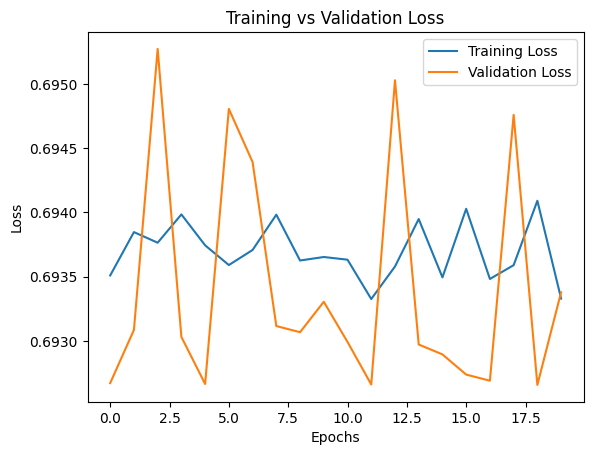

In [92]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import History

import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Data
# -------------------------------
df = pd.read_csv("final_vgsales.csv")

# -------------------------------
# 2. Target & Features
# -------------------------------
y = df["Hit_Game"]

drop_cols = [
    "Global_Sales",
    "Total_Sales_Check",
    "Sales_Per_Year",
    "Hit_Game",
    "Name"
]

X = df.drop(columns=drop_cols)

categorical_cols = ["Platform", "Genre", "Publisher"]
numeric_cols = ["Year", "Game_Age"]

# -------------------------------
# 3. Encoding
# -------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

# -------------------------------
# 4. Train / Validation Split
# -------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

# -------------------------------
# 5. Build ANN Model (2 hidden layers)
# -------------------------------
model = Sequential()

# Input layer + Hidden Layer 1
model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))

# Hidden Layer 2 (NEW)
model.add(Dense(32, activation="tanh"))

# Output Layer
model.add(Dense(1, activation="sigmoid"))

# -------------------------------
# 6. Compile
# -------------------------------
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------
# 7. Train (track validation)
# -------------------------------
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

# -------------------------------
# 8. Plot Loss (IMPORTANT)
# -------------------------------
plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()